<a href="https://colab.research.google.com/github/nouramar228-cyber/intermediate-ml-practice-solutions/blob/main/KMeans_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**KMeans Clustering (Core)**

**Task**

Your task is to perform customer segmentation using KMeans. We are interested in grouping our customers into groups based on similar characteristics. This can help the company effectively allocate marketing resources. We will use customer age, education, years of employment, income, debt, whether they defaulted, and their debt-to-income ratio to group them into segments.

You can download the data [here](https://assets.codingdojo.com/boomyeah2015/codingdojo/curriculum/content/chapter/cust_seg.csv). The original data is from this [data source](https://github.com/Nikhil-Adithyan/Customer-Segmentation-with-K-Means).

1. Use KMeans to create various customer segments.

   1. Use an Elbow Plot of inertia.
   2. And a plot of Silhouette Scores.
   3. Choose a K based on the results.





2. Analyze the clusters you made in Part 1.  
   1. Create analytical visualizations that explore statistics for each feature for each cluster.

   2. Write a description of each cluster based on the visualizations you created.

      1. Do more than describe the numbers; try to see beyond the numbers and describe the people represented by each cluster.

      2. Include at least one insight for each cluster.

 3. Create one or two recommendations for your stakeholders (the credit card company) regarding how they should market credit cards differently or which cards they should market to each cluster based on your data and insights.

**1. Load Data and preview Data**

In [ ]:
import pandas as pd
fpath = "/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/05-IntermediateML/Week18/Data/cust_seg.csv"
df = pd.read_csv(fpath)
df.head()

,Unnamed: 0,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,0,1,41,2,6,19,0.124,1.073,0.0,6.3
1,1,2,47,1,26,100,4.582,8.218,0.0,12.8
2,2,3,33,2,10,57,6.111,5.802,1.0,20.9
3,3,4,29,2,4,19,0.681,0.516,0.0,6.3
4,4,5,47,1,31,253,9.308,8.908,0.0,7.2


**3. Drop Unnecessary Columns**

In [ ]:
df.drop(columns=['Unnamed: 0','Customer Id'], inplace =True)
df

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,41,2,6,19,0.124,1.073,0.0,6.3
1,47,1,26,100,4.582,8.218,0.0,12.8
2,33,2,10,57,6.111,5.802,1.0,20.9
3,29,2,4,19,0.681,0.516,0.0,6.3
4,47,1,31,253,9.308,8.908,0.0,7.2
...,...,...,...,...,...,...,...,...
845,27,1,5,26,0.548,1.220,NaN,6.8
846,28,2,7,34,0.359,2.021,0.0,7.0
847,25,4,0,18,2.802,3.210,1.0,33.4
848,32,1,12,28,0.116,0.696,0.0,2.9


**4. EDA and Cleaning**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              850 non-null    int64  
 1   Edu              850 non-null    int64  
 2   Years Employed   850 non-null    int64  
 3   Income           850 non-null    int64  
 4   Card Debt        850 non-null    float64
 5   Other Debt       850 non-null    float64
 6   Defaulted        850 non-null    float64
 7   DebtIncomeRatio  850 non-null    float64
 8   cluster          850 non-null    int32  
dtypes: float64(4), int32(1), int64(4)
memory usage: 56.6 KB


In [ ]:
#check duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
#check missing values
df.isna().sum()

,0
Age,0
Edu,0
Years Employed,0
Income,0
Card Debt,0
Other Debt,0
Defaulted,150
DebtIncomeRatio,0


In [ ]:
mode = df['Defaulted'].mode()[0]
df['Defaulted'].fillna(mode, inplace=True)
df.isna().sum()

/tmp/ipykernel_11591/1775927825.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Defaulted'].fillna(mode, inplace=True)


,0
Age,0
Edu,0
Years Employed,0
Income,0
Card Debt,0
Other Debt,0
Defaulted,0
DebtIncomeRatio,0


**5. Scale Data**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

**6. Tune a KMeans Model and Cluster the Scaled Data**

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2,11)

inertias = []
sils = []

for k in ks:

    kmeans = KMeans(n_clusters=k,random_state=42,n_init='auto')
    kmeans.fit(X_scaled)

    inertias.append(kmeans.inertia_)

    sils.append(silhouette_score(X_scaled,kmeans.labels_))

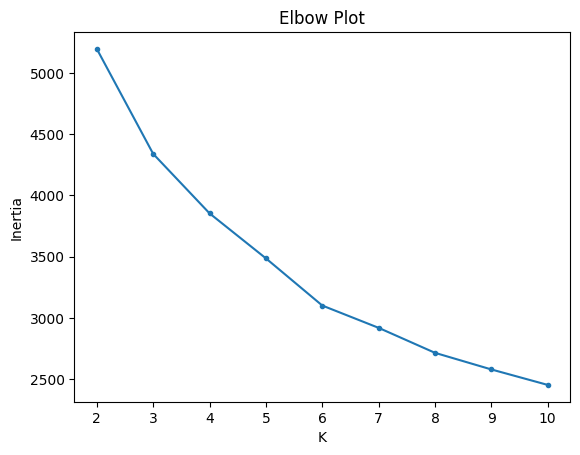

In [ ]:
import matplotlib.pyplot as plt

plt.plot(ks, inertias, marker=".")
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Plot')
plt.show()

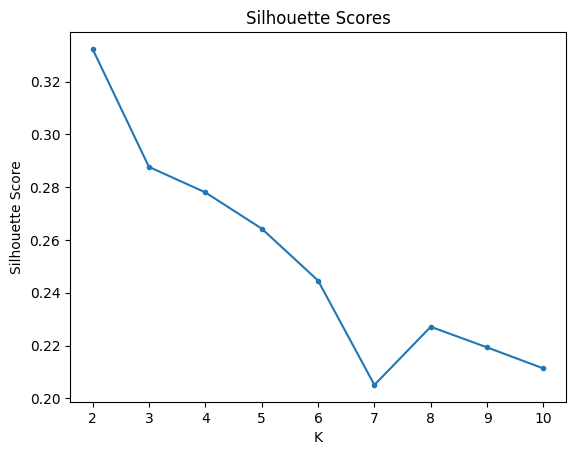

In [ ]:
plt.plot(ks, sils, marker=".")
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, n_init= 'auto', random_state=42)
kmeans.fit(X_scaled)
# Add the clusters as a column in the dataframe
df['cluster'] = kmeans.labels_
df.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio,cluster
0,41,2,6,19,0.124,1.073,0.0,6.3,0
1,47,1,26,100,4.582,8.218,0.0,12.8,2
2,33,2,10,57,6.111,5.802,1.0,20.9,1
3,29,2,4,19,0.681,0.516,0.0,6.3,0
4,47,1,31,253,9.308,8.908,0.0,7.2,3


In [ ]:
# Group the dataframe by cluster and aggregate by mean values
# Add as_index=False so that the clusters are a column, not the index
cluster_groups = df.groupby('cluster', as_index=False).mean()
cluster_groups

,cluster,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,0,33.111570,1.609504,6.731405,33.512397,0.775273,1.665585,0.000000,7.812190
1,1,31.682927,1.847561,3.859756,31.432927,1.569311,2.823598,0.987805,14.029268
2,2,42.047872,1.835106,16.345745,81.462766,2.890261,5.959500,0.069149,12.385638
3,3,46.285714,1.928571,22.642857,213.142857,11.737786,16.239857,0.571429,16.821429


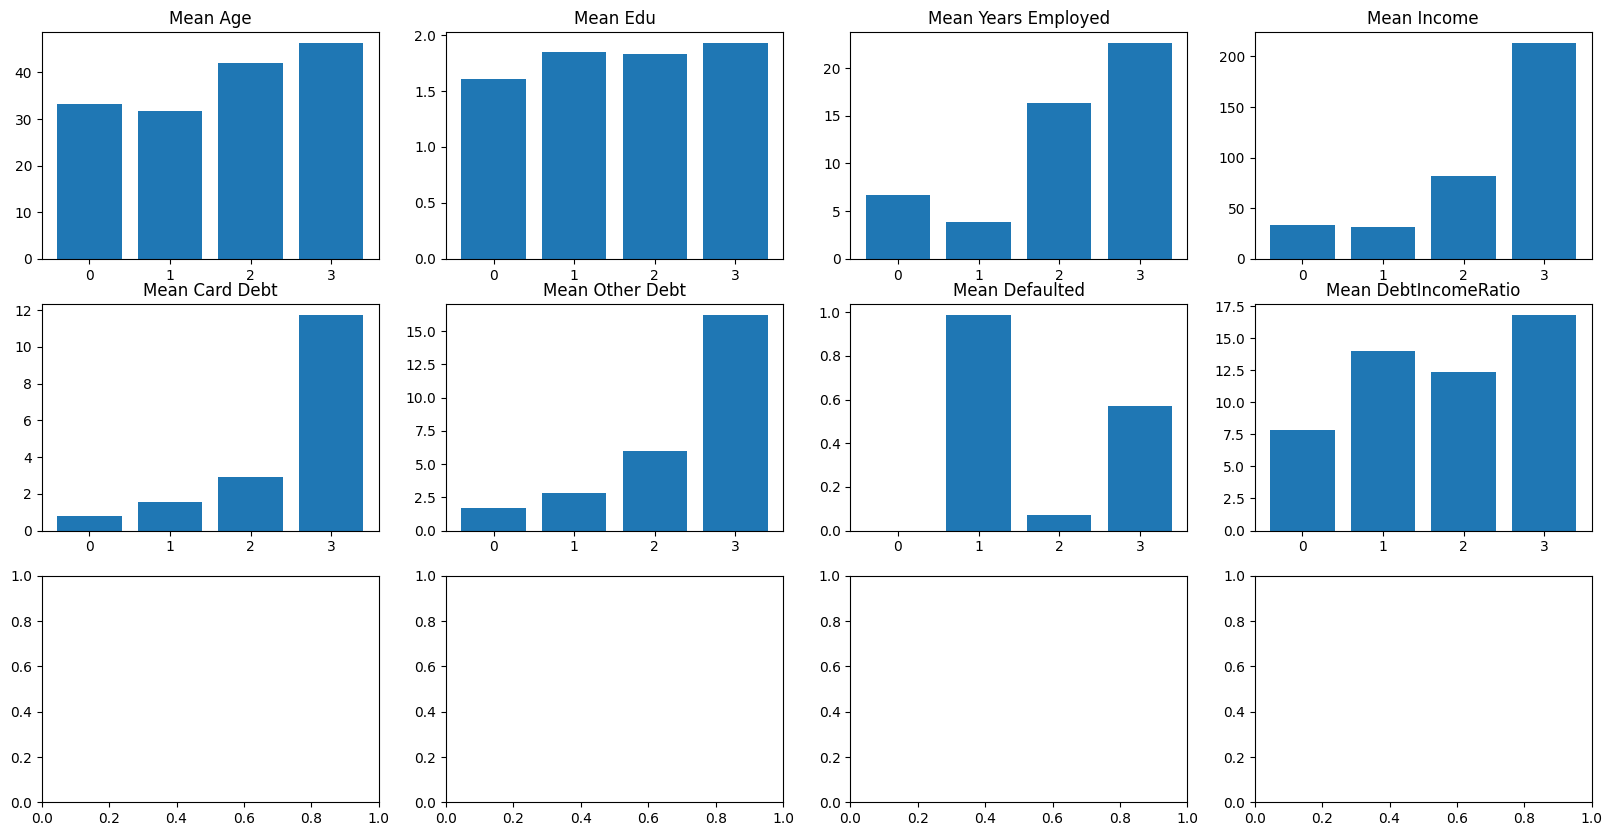

In [ ]:
fig, axes = plt.subplots(3,4, figsize = (20, 10))
# fig is an array of dimensions 3,4.  axes.ravel() will flatten it to 12,1
axes = axes.ravel()
# Loop over columns and plot each in a separate figure, skip 'cluster' column
for i, col in enumerate(cluster_groups.columns[1:]):
  axes[i].bar(cluster_groups['cluster'], cluster_groups[col])
  axes[i].set_title(f'Mean {col}')

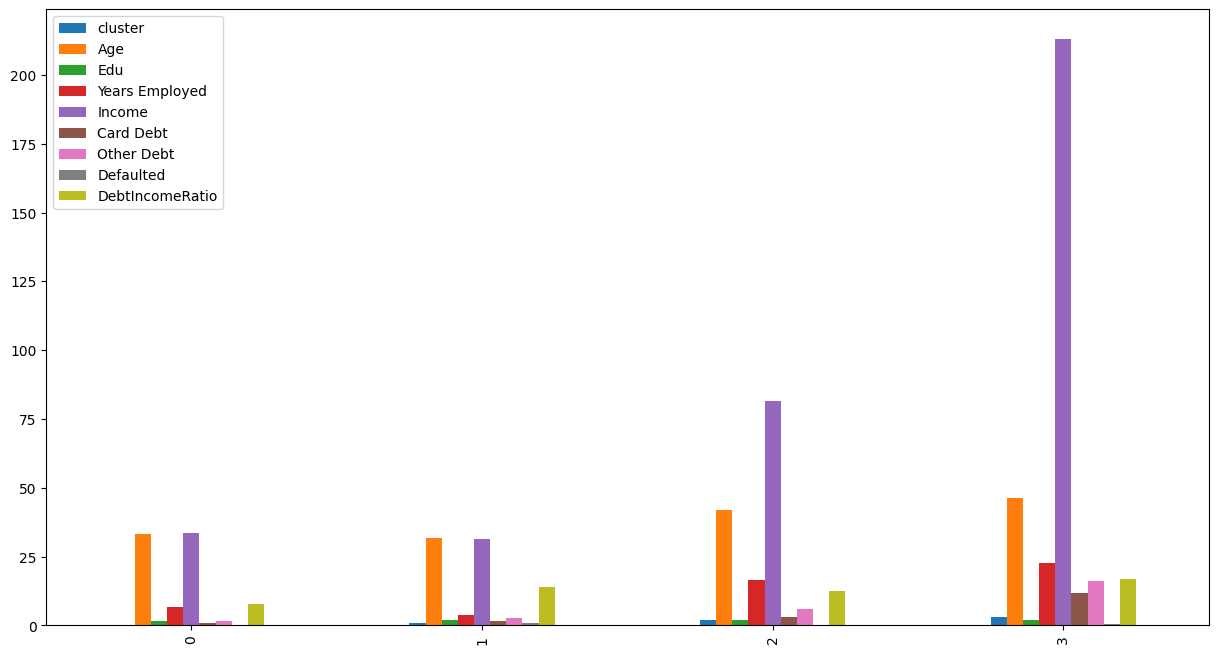

In [ ]:
cluster_groups.plot(
    kind='bar',
    figsize=(15,8)
)

plt.show()

**Cluster 0 — Financially Stable Young Customers**

**Characteristics:**

*   Average age: 33 years
*   Medium income (34K)
*   Low to moderate years employed
*   Low debt levels
*   Moderate default rate
*   Low debt-to-income ratio

**Analysis:**

This cluster represents relatively young customers who are beginning to establish financial stability. Their income is moderate, and they tend to maintain manageable debt levels.

Although they are not high earners yet, they also do not appear heavily financially burdened. Some customers may still have limited credit history, which could explain the moderate default behavior.

**Insight:**

These customers have strong long-term growth potential as their careers and incomes develop over time.

**Recommendations:**
Offer entry-level or mid-tier credit cards.
Promote credit-building programs.
Use cashback and basic rewards to encourage card usage and loyalty.

**Cluster 1 — Financially Vulnerable Customers**

**Characteristics:**
Youngest customer group

*  Youngest customer group
*  Lowest income (~31K)
*  Lowest years of employment
*  Highest default rate
*  Relatively high debt-to-income ratio





**Analysis:**

This cluster represents high-risk customers with lower financial stability. They are likely early in their careers or experiencing economic difficulties.

Their combination of low income, short employment history, and very high default levels makes them the riskiest segment for the credit card company.

**Insight:**

This group has the highest probability of future payment issues and credit default.

**Recommendations:**
* Avoid marketing premium credit cards to this group.
* Offer secured credit cards or low-limit starter cards.
* Provide financial education and debt-management support.
* Apply stricter approval criteria and lower credit limits.

**Cluster 2 — Stable Middle-Class Customers**

**Characteristics:**

* Average age around 42 years
* Good income (~80K)
* Strong employment stability
* Moderate debt levels
* Lowest default rate

**Analysis:**

This segment represents financially responsible middle-class customers. They have stable jobs, good incomes, and demonstrate healthy debt management behavior.

This is one of the most valuable and reliable customer groups for the company.

**Insight:**

These customers are highly profitable long-term clients with relatively low credit risk.

**Recommendations:**

* Market rewards and travel credit cards.
* Gradually increase credit limits.
* Offer loyalty programs and personalized promotions.

**Cluster 3 — High-Income Heavy Credit Users**

**Characteristics:**

Oldest customer group (46 years)
Highest income (215K)
Highest years employed
Highest card debt and other debt
High debt-to-income ratio
Moderate default rate

**Analysis:**

This cluster represents wealthy customers who heavily use credit products. Although they earn significantly more than other groups, they also carry high levels of debt and financial commitments.

These customers likely rely on credit frequently for lifestyle spending, travel, business expenses, or investments.

**Insight:**

This group can generate substantial revenue for the company, but their high debt exposure still requires careful risk monitoring.

**Recommendations:**
* Offer premium and luxury credit cards.
* Promote travel rewards, airport lounge access, and VIP services.
* Provide personalized banking and exclusive benefits.
* Monitor debt behavior closely to manage financial risk.